In [1]:
import pandas as pd
import numpy as np
import pickle
from ScanImageTiffReader import ScanImageTiffReader
import os
import matplotlib.pyplot as plt
import scipy.signal
from scipy.stats import norm
from tqdm import tqdm
import tifffile
from scipy.signal import butter, lfilter,find_peaks, convolve
from scipy.signal.windows import gaussian
from ibllib.io.video import *
import scipy.ndimage
import cv2
from matplotlib.animation import FuncAnimation, FFMpegWriter
from IPython.display import HTML
from matplotlib.animation import PillowWriter
from ScanImageTiffReader import ScanImageTiffReader
import json
from murphlib.caimage import *
from murphlib.tools import *
from murphlib.plotting import *
from murphlib.regression import *
from sklearn.decomposition import PCA
from sklearn.metrics import explained_variance_score
from scipy.stats import zscore
import scipy.io
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
import seaborn as sns
import ibllib.io.raw_data_loaders as rawio
from ibllib.io.extractors.training_wheel import get_wheel_position, extract_wheel_moves, extract_wheel_velocity
import brainbox.behavior.wheel as wh
plt.rcParams['animation.ffmpeg_path'] = r'D:\ffmpeg\bin\ffmpeg.exe'

In [62]:
import gc
plt.close('all')
gc.collect()

246

In [ ]:
atlas_template = np.load(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\Registration\atlas_template_slice51.npy')
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template, cmap='gray')

In [ ]:
tv = np.load(r'D:\Lab_Analysis\allenCCF\template_volume_10um.npy')
atlas_template = create_angled_slice(
        tv, 
        pitch_angle=15,  # 15 degrees nose down
        roll_angle=3,     # roll along ant-post axis, + rolls to the left
        slice_height=65
    )
atlas_template = atlas_template[999:1230, 199:940]
plt.imshow(atlas_template,cmap='gray')

In [2]:
agg_data = {}
behav_train_path = r'Z:\TM_Lab\Edward\Data\iblrig_data\Subjects'
ca_img_path = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m'
mouse_ids = ['AE_L2', 'AE_L3', 'AF_R3', 'AF_L2', 'AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'O_R2'] 
#mouse_ids = ['AF_L3', 'AB_R2', 'A_R2', 'A_R3','J_L2', 'AF_L2'] 
# mouse_ids = ['AE_L2']
for mouse in mouse_ids:
    mouse_path = os.path.join(ca_img_path, mouse)
    
    subdir = [d for d in os.listdir(mouse_path)]
    dates = [s for s in subdir if (
        s.isdigit() or 
        (s.endswith('_valvesilent') and s[:-12].isdigit()) or
        (s.endswith('_valvesilent_punishsilent') and s[:-25].isdigit())
    )]

    mouse_data = {key: {} for key in dates + ['training']}
    for date in dates:
        session_path = os.path.join(mouse_path, date)
        bhv_path = os.path.join(session_path, 'behavior')
        facemap_folder = os.path.join(bhv_path, 'raw_video_data')
        subdir = [d for d in os.listdir(session_path)]
        if 'arm1' in subdir:
            arm1_img_path = os.path.join(session_path, 'arm1')
            arm1_stat = get_stat_with_coord(arm1_img_path)
            arm1_ridge_model = np.load(os.path.join(arm1_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm1_ridge_model[0]['predictors']
            unique_predictors = arm1_ridge_model[0]['unique_predictors']
            arm1_stat = attach_reg_model_to_stat(arm1_stat, arm1_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm1'] = {}
            mouse_data[date]['arm1']['stat'] = np.array(arm1_stat, dtype=object)
            mouse_data[date]['arm1']['table_for_img'] = pd.read_csv(arm1_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm1']['design_matrix'] = np.load(os.path.join(arm1_img_path, 'design_matrix.npy'))

        if 'arm2' in subdir:
            arm2_img_path = os.path.join(session_path, 'arm2')
            arm2_stat = get_stat_with_coord(arm2_img_path)
            arm2_ridge_model = np.load(os.path.join(arm2_img_path, 'ridge_model_with_bootstrap_with_vel_lastmove_choice.npy'), allow_pickle=True)
            predictors = arm2_ridge_model[0]['predictors']
            unique_predictors = arm2_ridge_model[0]['unique_predictors']
            arm2_stat = attach_reg_model_to_stat(arm2_stat, arm2_ridge_model) # bonferroni correction applied to bootstrap p-values
            mouse_data[date]['arm2'] = {}
            mouse_data[date]['arm2']['stat'] = np.array(arm2_stat, dtype=object)
            mouse_data[date]['arm2']['table_for_img'] = pd.read_csv(arm2_img_path+'\\table_for_regression.csv')
            mouse_data[date]['arm2']['design_matrix'] = np.load(os.path.join(arm2_img_path, 'design_matrix.npy'))
        mouse_data[date]['pupil_area'] = np.load(os.path.join(facemap_folder, 'pupil_area.npy')) # synced to table for video
        mouse_data[date]['pupil_xpos'] = np.load(os.path.join(facemap_folder, 'pupil_xpos.npy'))
        mouse_data[date]['pupil_ypos'] = np.load(os.path.join(facemap_folder, 'pupil_ypos.npy'))
        mouse_data[date]['body_motion'] = np.load(os.path.join(facemap_folder, 'bodymotion_svd.npy'))
        mouse_data[date]['face_motion'] = np.load(os.path.join(facemap_folder, 'facemotion_svd.npy'))
        mouse_data[date]['lick'] = np.load(os.path.join(facemap_folder, 'lickmotion_svd.npy'))
        mouse_data[date]['pupil_area'] = fill_nan_with_previous(mouse_data[date]['pupil_area'])
        mouse_data[date]['pupil_xpos'] = fill_nan_with_previous(mouse_data[date]['pupil_xpos'])
        mouse_data[date]['pupil_ypos'] = fill_nan_with_previous(mouse_data[date]['pupil_ypos'])
        mouse_data[date]['table_for_video'] = pd.read_csv(bhv_path+'\\table_for_video.csv')
        mouse_data[date]['trials_table'] = pd.read_parquet(bhv_path+'\\alf\\_ibl_trials.table.pqt')
        
        bpod_trials = rawio.load_data(bhv_path, task_collection='raw_behavior_data')
        ts, pos = get_wheel_position(bhv_path, bpod_trials, task_collection='raw_behavior_data')
        interp_pos, interp_ts = wh.interpolate_position(ts, pos, freq=1000)
        wheel_moves = extract_wheel_moves(ts, pos, display=False)
        mouse_data[date]['wheel_vel'] = extract_wheel_velocity(interp_pos) # synced to trials table
        mouse_data[date]['wheel_ts'] = interp_ts
        mouse_data[date]['wheel_pos'] = interp_pos
    
    os.makedirs(os.path.join(mouse_path, 'figures'), exist_ok=True)
    mouse_data['training']['accuracies_vis'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_vis.npy')) 
    mouse_data['training']['accuracies_aud'] = np.load(os.path.join(behav_train_path,mouse, 'accuracies_aud.npy'))
    mouse_data['training']['num_trials'] = np.load(os.path.join(behav_train_path,mouse, 'num_trials.npy'))  
    mouse_data['training']['training_dates'] = np.load(os.path.join(behav_train_path,mouse, 'training_dates.npy'))
    psth_time_start = -0.4
    psth_time_end = 1.2
    event_preds = unique_predictors[:15]
    
    
    for predi, pred in enumerate(event_preds):
        pred_idx = [i for i, name in enumerate(predictors) if pred in name]
        for dayi, date in enumerate(dates):
            session_path = os.path.join(mouse_path, date)
            if 'arm1' in mouse_data[date]:
                arm1_img_path = os.path.join(session_path, 'arm1')
                arm1_table_for_img = pd.read_csv(arm1_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm1_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm1_img_meta = json.load(json_file)
                frame_rate_arm1 = arm1_img_meta['SI.hRoiManager.scanFrameRate']
                arm1_dff = np.load(os.path.join(arm1_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy'))    
                tf_arm1_table_for_img = mouse_data[date]['arm1']['table_for_img']
                arm1_bsl_psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm1_bsl_psth = get_trial_PSTH(arm1_dff, arm1_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm1_bsl_psth = arm1_bsl_psth.reshape(arm1_bsl_psth.shape[0], -1)
                arm1_bsl_mean = np.mean(arm1_bsl_psth, axis=1)
                arm1_bsl_sd = np.std(arm1_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm1_table_for_img, frame_rate_arm1, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm1_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm1_bsl_mean[np.newaxis, :, np.newaxis]) / arm1_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
            if 'arm2' in mouse_data[date]:  
                arm2_img_path = os.path.join(session_path, 'arm2')
                arm2_table_for_img = pd.read_csv(arm2_img_path+'\\table_for_img.csv')
                with open(os.path.join(arm2_img_path, 'ca_img_wholefile_metadata.json'), 'r') as json_file:
                    arm2_img_meta = json.load(json_file)
                frame_rate_arm2 = arm2_img_meta['SI.hRoiManager.scanFrameRate']
                arm2_dff = np.load(os.path.join(arm2_img_path, 'dff_moving_percentile_pc_lowpass_0p5hz.npy')) 
                tf_arm2_table_for_img = mouse_data[date]['arm2']['table_for_img']
                arm2_bsl_psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (-0.4, -0.067), 'ruleCueTrigger_times').astype(int)
                arm2_bsl_psth = get_trial_PSTH(arm2_dff, arm2_bsl_psth_frame_idx, zscore=False).transpose(1, 0, 2)
                arm2_bsl_psth = arm2_bsl_psth.reshape(arm2_bsl_psth.shape[0], -1)
                arm2_bsl_mean = np.mean(arm2_bsl_psth, axis=1)
                arm2_bsl_sd = np.std(arm2_bsl_psth, axis=1)
                psth_frame_idx = find_frame_indices(tf_arm2_table_for_img, frame_rate_arm2, (psth_time_start, psth_time_end), pred).astype(int)
                if len(psth_frame_idx) != 0:
                    all_psth = get_trial_PSTH(arm2_dff, psth_frame_idx, zscore=False)
                    z_psth = (all_psth - arm2_bsl_mean[np.newaxis, :, np.newaxis]) / arm2_bsl_sd[np.newaxis, :, np.newaxis]
                    mean_psth = np.mean(all_psth, axis=0)
                    mean_z_psth = np.mean(z_psth, axis=0)
                    for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                        beta = neuron['beta'][pred_idx]
                        neuron[pred+'_beta'] = beta
                        neuron[pred+'_psth_raw'] = np.squeeze(all_psth[:,i,:])
                        neuron[pred+'_psth'] = np.squeeze(z_psth[:,i,:])
    agg_data[mouse] = mouse_data
    

2025-10-21 22:20:59.477 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 117657  Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\AE_L2\20250729_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2025-10-21 22:23:15.523 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 113967  Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\AE_L3\20250617_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2025-10-21 22:25:17.576 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 66038  Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\AE_L3\20250722_valvesilent\behavior\raw_behavior_data\_iblrig_encoderPositions.raw.ssv
2025-10-21 22:25:17.592 WARNING  [raw_data_loaders.py:655] _iblrig_encoderPositions.raw.ssv rotary encoder timestamps swapped at index: 177585  Z:\TM_Lab\Edwa

In [3]:
date

'20241219'

In [9]:
def rolling_average(data, window_size):
    result = np.empty_like(data, dtype=float)
    
    for i in range(len(data)):
        start_idx = max(0, i - window_size + 1)
        result[i] = np.mean(data[start_idx:i+1])
    
    return result


In [ ]:
vis_perf = rolling_average(agg_data['AE_L2']['training']['accuracies_vis'],5)
aud_perf = rolling_average(agg_data['AE_L2']['training']['accuracies_aud'],5)
plt.plot(vis_perf)
plt.plot(aud_perf)

In [ ]:
agg_data['AE_L2']['training']['training_dates']

47

In [41]:
for mouse in mouse_ids:
    mouse_data = agg_data[mouse]
    vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
    aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
    training_dates = mouse_data['training']['training_dates']
    img_dates = [s[:8] for s in mouse_data.keys() if s.isdigit() or 
        s.endswith('_valvesilent') and s.replace('_valvesilent', '').isdigit() or
        s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent', '').isdigit()]
    print(img_dates)
    perf_thresh = 0.65
    for date in img_dates:
        training_day_num = np.where(training_dates==date)[0]
        
        if (vis_perf[training_day_num] > perf_thresh and aud_perf[training_day_num] > perf_thresh) or (mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh and mouse_data['training']['accuracies_aud'][training_day_num] > perf_thresh):
            status = 'db_expert'
            
        elif vis_perf[training_day_num] > perf_thresh or mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh:
            status = 'vis_expert'
            
        elif aud_perf[training_day_num] > perf_thresh or mouse_data['training']['accuracies_aud'][training_day_num] > perf_thresh:
            status = 'aud_expert'
            
        else:
            status = 'naive'
        print(mouse, date, status)
            

['20250612', '20250624', '20250701', '20250708', '20250715', '20250729', '20250814', '20250821']
AE_L2 20250612 naive
AE_L2 20250624 naive
AE_L2 20250701 naive
AE_L2 20250708 naive
AE_L2 20250715 naive
AE_L2 20250729 vis_expert
AE_L2 20250814 db_expert
AE_L2 20250821 db_expert
['20250612', '20250617', '20250624', '20250701', '20250708', '20250722', '20250729', '20250812', '20250820', '20250828', '20250903', '20250909']
AE_L3 20250612 naive
AE_L3 20250617 naive
AE_L3 20250624 naive
AE_L3 20250701 naive
AE_L3 20250708 naive
AE_L3 20250722 aud_expert
AE_L3 20250729 aud_expert
AE_L3 20250812 aud_expert
AE_L3 20250820 aud_expert
AE_L3 20250828 db_expert
AE_L3 20250903 db_expert
AE_L3 20250909 aud_expert
['20250528', '20250604', '20250611', '20250618', '20250625', '20250702', '20250710', '20250716', '20250723', '20250730', '20250814', '20250821', '20250828', '20250904', '20250909']
AF_R3 20250528 naive
AF_R3 20250604 naive
AF_R3 20250611 naive
AF_R3 20250618 naive
AF_R3 20250625 naive
AF_R3 

C:\Users\dirk\AppData\Local\Temp\ipykernel_23440\935619320.py:14: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  if (vis_perf[training_day_num] > perf_thresh and aud_perf[training_day_num] > perf_thresh) or (mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh and mouse_data['training']['accuracies_aud'][training_day_num] > perf_thresh):
C:\Users\dirk\AppData\Local\Temp\ipykernel_23440\935619320.py:17: DeprecationWarning: The truth value of an empty array is ambiguous. Returning False, but in future this will result in an error. Use `array.size > 0` to check that an array is not empty.
  elif vis_perf[training_day_num] > perf_thresh or mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh:
C:\Users\dirk\AppData\Local\Temp\ipykernel_23440\935619320.py:20: DeprecationWarning: The truth value of an empty array 

In [ ]:
os.makedirs(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate', exist_ok=True)
event_preds = unique_predictors[:1]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]

    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        perf_thresh = 0.65
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if (vis_perf[training_day_num] > perf_thresh and aud_perf[training_day_num] > perf_thresh) or (mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh and mouse_data['training']['accuracies_aud'][training_day_num] > perf_thresh):
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > perf_thresh or mouse_data['training']['accuracies_vis'][training_day_num] > perf_thresh:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > perf_thresh or mouse_data['training']['accuracies_aud'][training_day_num] > perf_thresh:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            
            if 'arm1' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm1']['stat']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], 
                      c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), 
                      cmap='coolwarm', 
                      vmin=-0.01, 
                      vmax=0.01, 
                      s=0.001,
                      alpha=0.3)
            if 'arm2' in mouse_data[date]:
                for i, neuron in enumerate(mouse_data[date]['arm2']['stat']):
                    #beta = zscore(neuron['beta'][pred_idx])
                    #midpoint = (len(beta)+1)//2
                    #resp_beta = np.mean(beta[midpoint:midpoint+int(0.4*15)])
                    resp_beta = np.mean(neuron['beta'][pred_idx])
                    #print(resp_beta)
                    axes[row, col].scatter(neuron['xcoord_atlas'], neuron['ycoord_atlas'], 
                      c=np.repeat(resp_beta,len(neuron['xcoord_atlas'])), 
                      cmap='coolwarm', 
                      vmin=-0.01, 
                      vmax=0.01, 
                      s=0.001,
                      alpha=0.3)
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate', 'beta_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)
    

In [ ]:
event_preds = unique_predictors[:10]
for pred in event_preds:
    pred_idx = [i for i, name in enumerate(predictors) if pred in name]
    unique_pred_idx = unique_predictors.index(pred)
    fig, axes = plt.subplots(2,2,figsize = (30,15))
    for idx in np.ndindex(axes.shape):
        row_idx, col_idx = idx
        ax = axes[idx]
        ax.imshow(atlas_template,cmap='gray')
        ax.set_xticks([])
        ax.set_yticks([])
    axes[0,0].set_title('Naive', fontsize = 30)
    axes[0,1].set_title('Vis expert', fontsize = 30)
    axes[1,0].set_title('Aud expert', fontsize = 30)
    axes[1,1].set_title('Double expert', fontsize = 30)
    fig.suptitle(pred, fontsize=30)
    for mouse in mouse_ids:
        mouse_data = agg_data[mouse]
        vis_perf = rolling_average(mouse_data['training']['accuracies_vis'],3)
        aud_perf = rolling_average(mouse_data['training']['accuracies_aud'],3)
        training_dates = mouse_data['training']['training_dates']
        img_dates = [i for i in mouse_data.keys() if i.isdigit()]
        
        for date in img_dates:
            training_day_num = np.where(training_dates==date)[0]
            if vis_perf[training_day_num] > 0.7 and aud_perf[training_day_num] > 0.7:
                status = 'db_expert'
                row = 1
                col = 1
            elif vis_perf[training_day_num] > 0.7:
                status = 'vis_expert'
                row = 0
                col= 1
            elif aud_perf[training_day_num] > 0.7:
                status = 'aud_expert'
                row = 1
                col = 0
            else:
                status = 'naive'
                row = 0
                col = 0
            ax = axes[row,col]
            if 'arm1' in mouse_data[date]:
                stat = mouse_data[date]['arm1']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001,
                        alpha=0.3
                    )

            # Plot arm2 neurons
            # Plot arm2 neurons
            if 'arm2' in mouse_data[date]:
                stat = mouse_data[date]['arm2']
                for i, neuron in enumerate(np.array(stat)):
                    if neuron['celltype'] == 'soma':
                        continue
                    bootstrap_p = holm_bonferroni_correction(neuron['bootstrap_p_value'])
                    r2 = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = bootstrap_p[unique_pred_idx]
                    r2 = 0 if p_value > 0.05 else r2
                    color = r2  # Gray for non-significant, R² for significant
                    #color = r2
                    ax.scatter(
                        neuron['xcoord_atlas'], 
                        neuron['ycoord_atlas'], 
                        c=color if color == 'gray' else np.repeat(r2, len(neuron['xcoord_atlas'])), 
                        cmap='coolwarm', 
                        vmin=-0.02, vmax=0.02, 
                        s=0.001,
                        alpha=0.3
                    )
    fig.tight_layout()
    fig.savefig(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs', 'unique_r2_'+ pred + '_topo.png'),
                dpi=300,               # High resolution for publication
                bbox_inches='tight',   # Prevent clipping
                )
    plt.close(fig)

In [7]:
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# -------------------------------
# Utility helpers
# -------------------------------

def rolling_average(x, w=3):
    x = np.asarray(x, dtype=float)
    if w <= 1 or x.size == 0:
        return x
    pad = np.pad(x, (w-1, 0), mode='edge')
    c = np.cumsum(pad)
    out = (c[w:] - c[:-w]) / w
    head = np.full(w-1, out[0])
    return np.concatenate([head, out])

def classify_day_stage(vis_perf, aud_perf, vis_raw, aud_raw, perf_thresh=0.65):
    """
    Returns: 'naive' | 'vis_expert' | 'aud_expert' | 'db_expert'
    Prefers rolling perf; falls back to raw day perf.
    """
    v = float(vis_perf) if np.isfinite(vis_perf) else float(vis_raw)
    a = float(aud_perf) if np.isfinite(aud_perf) else float(aud_raw)
    v_ok = (v > perf_thresh) or (vis_raw > perf_thresh)
    a_ok = (a > perf_thresh) or (aud_raw > perf_thresh)
    if v_ok and a_ok:   return 'db_expert'
    if v_ok and not a_ok: return 'vis_expert'
    if a_ok and not v_ok: return 'aud_expert'
    return 'naive'

def robust_symmetric_clim(maps, pct=99.0, fallback=0.01):
    vals = []
    for m in maps:
        if m is None: 
            continue
        v = m[np.isfinite(m)]
        if v.size:
            vals.append(np.abs(v).ravel())
    if not vals:
        return (-fallback, fallback)
    allabs = np.concatenate(vals)
    lim = np.percentile(allabs, pct)
    lim = max(lim, fallback)
    return (-lim, lim)

# -------------------------------
# Rasterization (per-pixel) bins
# -------------------------------

def _bin_edges_from_extent(xlim, ylim, binsize):
    nbx = max(2, int(np.ceil((xlim[1] - xlim[0]) / binsize)))
    nby = max(2, int(np.ceil((ylim[1] - ylim[0]) / binsize)))
    xedges = np.linspace(xlim[0], xlim[1], nbx+1)
    yedges = np.linspace(ylim[0], ylim[1], nby+1)
    return xedges, yedges, nbx, nby

def rasterize_dendrites_full_atlas(
    neurons,
    atlas_shape,              # (H, W) from atlas_template.shape
    downsample=4,
    min_count=10,
    smooth_sigma_bins=1.0,
    weighting='length'        # 'length' | 'unit' | 'none'
):
    """
    Rasterizes dendrite pixels over the FULL atlas (0..W, 0..H) on a downsampled grid.
    Returns:
      H_mean (ny_ds, nx_ds), H_count (ny_ds, nx_ds), extent=[0,W,0,H]
    """
    H, W = map(int, atlas_shape)
    assert H > 0 and W > 0

    # downsampled grid size
    nx_ds = (W + downsample - 1) // downsample
    ny_ds = (H + downsample - 1) // downsample
    nb = nx_ds * ny_ds

    H_count_flat = np.zeros(nb, dtype=np.float32)
    H_sum_flat   = np.zeros(nb, dtype=np.float32)

    inv_ds = 1.0 / float(downsample)

    for neu in neurons:
        x = np.asarray(neu['xcoord_atlas']).ravel().astype(np.int64)  # columns
        y = np.asarray(neu['ycoord_atlas']).ravel().astype(np.int64)  # rows
        d = float(neu['data'])
        if x.size == 0 or y.size == 0 or not np.isfinite(d):
            continue

        # Clip to full atlas bounds
        ok = (x >= 0) & (x < W) & (y >= 0) & (y < H)
        if not np.any(ok):
            continue
        x = x[ok]; y = y[ok]

        # Downsampled bin indices in full field
        ix_ds = (x * inv_ds).astype(np.int64)  # 0..nx_ds-1
        iy_ds = (y * inv_ds).astype(np.int64)  # 0..ny_ds-1
        lin = (iy_ds * nx_ds + ix_ds)

        # Unique bins hit by this neuron + pixel counts
        u, c = np.unique(lin, return_counts=True)

        if weighting == 'unit':
            total = c.sum()
            wcounts = (c / total).astype(np.float32) if total > 0 else np.zeros_like(c, dtype=np.float32)
        elif weighting == 'none':
            wcounts = np.ones_like(c, dtype=np.float32)
        else:  # 'length'
            wcounts = c.astype(np.float32)

        H_count_flat[u] += wcounts
        H_sum_flat[u]   += wcounts * d

    with np.errstate(invalid='ignore', divide='ignore'):
        H_mean_flat = H_sum_flat / H_count_flat

    H_count = H_count_flat.reshape(ny_ds, nx_ds)
    H_mean  = H_mean_flat.reshape(ny_ds, nx_ds)

    # Mask sparse bins
    H_mean[H_count < min_count] = np.nan

    # Optional smoothing preserving NaNs
    if smooth_sigma_bins and smooth_sigma_bins > 0:
        mask = np.isfinite(H_mean)
        Hf = np.where(mask, H_mean, 0.0)
        wf = gaussian_filter(mask.astype(float), smooth_sigma_bins, mode='nearest')
        hf = gaussian_filter(Hf, smooth_sigma_bins, mode='nearest')
        H_mean = np.where(wf > 1e-9, hf / wf, np.nan)

    extent = [0, W, 0, H]
    return H_mean, H_count, extent


def make_stage_maps_rasterized_full_atlas(
    agg_data,
    mouse_ids,
    atlas_template,               # 2D background image
    pred_name,
    predictors,
    perf_thresh=0.65,
    downsample=4,                 # spatial downsample factor
    smooth_sigma_bins=1.0,
    min_count=10,
    zscore_within_session=False,
    frame_reduction='mean',       # 'mean' or 'sum' across predictor lags
    weighting='length',            # 'length'|'unit'|'none'
    data_type='beta'
):
    """
    2x2 stage maps on the FULL atlas field using per-pixel rasterization.
    """
    pred_idx = [i for i, nm in enumerate(predictors) if pred_name in nm]
    if not pred_idx:
        raise ValueError(f"Predictor '{pred_name}' not found in predictors list.")
    unique_pred_idx = unique_predictors.index(pred_name)
    H, W = atlas_template.shape
    pooled = {k: [] for k in ['naive','vis_expert','aud_expert','db_expert']}

    for mouse in mouse_ids:
        md = agg_data[mouse]
        vis_acc = np.asarray(md['training']['accuracies_vis'])
        aud_acc = np.asarray(md['training']['accuracies_aud'])
        tr_dates = np.asarray(md['training']['training_dates'])
        vis_roll = rolling_average(vis_acc, w=3)
        aud_roll = rolling_average(aud_acc, w=3)

        img_dates = [s for s in md.keys() if (s.isdigit()
                   or (s.endswith('_valvesilent') and s.replace('_valvesilent','').isdigit())
                   or (s.endswith('_valvesilent_punishsilent') and s.replace('_valvesilent_punishsilent','').isdigit()))]

        for date in img_dates:
            #print('Aggregating mouse ' + mouse + ' date: ' + date + '...')
            if 'valvesilent' not in date and 'reward' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for reward...')
                continue
            if 'punishsilent' not in date and 'punish' in pred_name:
                print('Skipping ' + mouse + ' date: ' + date + ' for punish...')
                continue
            idx = np.where(tr_dates == date[:8])[0]
            if idx.size == 0:
                continue
            di = int(idx[0])
            stage = classify_day_stage(vis_roll[di], aud_roll[di], vis_acc[di], aud_acc[di], perf_thresh)

            session_neurons, session_data = [], []
            for arm in ['arm1','arm2']:
                if arm not in md[date]:
                    continue
                for neuron in md[date][arm]['stat']:
                    if data_type == 'beta':
                        beta_arr = np.asarray(neuron['beta'])[pred_idx].reshape(-1)
                        d = float(np.nanmean(beta_arr)) if frame_reduction == 'mean' else float(np.nansum(beta_arr))
                    elif data_type == 'r2':
                        d = neuron['unique_explained_variance'][unique_pred_idx]
                    p_value = neuron['bootstrap_p_value'][unique_pred_idx]
                    if p_value > 0.01:
                        d = 0
                    x = np.asarray(neuron['xcoord_atlas']).ravel()
                    y = np.asarray(neuron['ycoord_atlas']).ravel()
                    if x.size == 0 or y.size == 0 or not np.isfinite(d):
                        continue

                    session_neurons.append({'xcoord_atlas': x, 'ycoord_atlas': y, 'data': d})
                    session_data.append(d)

            if not session_neurons:
                continue

            if zscore_within_session:
                sb = np.asarray(session_data, dtype=float)
                mu = np.nanmean(sb); sd = np.nanstd(sb)
                zsb = np.zeros_like(sb) if (not np.isfinite(sd) or sd == 0.0) else (sb - mu) / sd
                for i in range(len(session_neurons)):
                    session_neurons[i]['data'] = float(zsb[i])

            pooled[stage].extend(session_neurons)

    # Build maps per stage on the FULL atlas
    stage_maps = {}
    extent = [0, W, 0, H]
    for stage in ['naive','vis_expert','aud_expert','db_expert']:
        print('build map for ' + stage + '...')
        neurons = pooled[stage]
        if not neurons:
            stage_maps[stage] = None
            continue
        H_mean, H_count, _ = rasterize_dendrites_full_atlas(
            neurons=neurons,
            atlas_shape=atlas_template.shape,
            downsample=downsample,
            min_count=min_count,
            smooth_sigma_bins=smooth_sigma_bins,
            weighting=weighting
        )
        stage_maps[stage] = H_mean

    # Color limits shared across panels
    #vmin, vmax = robust_symmetric_clim([stage_maps[s] for s in stage_maps], pct=99.0, fallback=0.01)
    if data_type == 'beta':
        vmin, vmax = -0.01, 0.01
    elif data_type == 'r2':
        vmin, vmax = -0.04, 0.04

    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 10), constrained_layout=True)
    panel_order  = ['naive','vis_expert','aud_expert','db_expert']
    panel_titles = ['Naive','Vis expert','Aud expert','Double expert']
    im_last = None

    for ax, stg, title in zip(axes.ravel(), panel_order, panel_titles):
        ax.imshow(atlas_template, cmap='gray', extent=[0, W, 0, H], origin='upper')
        Hm = stage_maps[stg]
        if Hm is not None:
            im_last = ax.imshow(
                Hm, cmap='coolwarm', vmin=vmin, vmax=vmax,
                extent=extent, origin='upper', alpha=0.7, interpolation='nearest'
            )
        ax.set_aspect('equal', adjustable='box')
        ax.set_title(title, fontsize=14)
        ax.set_xticks([]); ax.set_yticks([])

    if im_last is not None:
        cbar = fig.colorbar(im_last, ax=axes.ravel().tolist(), shrink=0.8)
        cbar.set_label(f"Mean β for '{pred_name}'" + (" (z-scored per session)" if zscore_within_session else ""), rotation=90)

    return fig, axes, stage_maps, extent

In [7]:
agg_data['AE_L2']['20250612']['arm1']['stat'][0]['ycoord_atlas']

array([40.75560414, 40.75681622, 40.7580283 , 40.90587839, 40.90709047,
       40.90830255, 40.90951463, 40.91072671, 40.91193879, 40.91315087,
       41.05736471, 41.05857679, 41.05978887, 41.06100095, 41.06221303,
       41.06342511, 41.06463719, 41.21006312, 41.2112752 , 41.21248728,
       41.21369936, 41.21491144, 41.21612352, 41.2173356 , 41.21854768,
       41.36033737, 41.36154945, 41.36276153, 41.36397361, 41.36518569,
       41.36639777, 41.36760985, 41.36882193, 41.37003401, 41.37124609,
       41.51303578, 41.51424786, 41.51545994, 41.51667202, 41.5178841 ,
       41.51909618, 41.52030826, 41.52152034, 41.52273242, 41.5239445 ,
       41.66452211, 41.66573419, 41.66694627, 41.66815835, 41.66937043,
       41.67058251, 41.67179459, 41.67300667, 41.67421875, 41.67543083,
       41.67664291, 41.81722051, 41.81843259, 41.81964467, 41.82085675,
       41.82206883, 41.82328091, 41.82449299, 41.82570507, 41.82691715,
       41.82812923, 41.82934131, 41.96991892, 41.971131  , 41.97

In [22]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [66]:
os.makedirs(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\beta', exist_ok=True)
os.makedirs(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2', exist_ok=True)

In [73]:
# pred_name = unique_predictors[:15]  # e.g., 'stim_onset', 'choice_left', ...
for pred_name in unique_predictors:
    fig, axes, stage_maps, extent = make_stage_maps_rasterized_full_atlas(
        agg_data=agg_data,
        mouse_ids=mouse_ids,
        atlas_template=atlas_template,
        pred_name=pred_name,
        predictors=predictors,
        perf_thresh=0.65,
        downsample=2,                # try 8 for speed, 2 for detail
        smooth_sigma_bins=1.0,
        min_count=50,                # bump a bit if downsample is small
        zscore_within_session=False,
        frame_reduction='mean',
        weighting='length' ,          # or 'unit' to equalize per-neuron contribution
        data_type='r2'
    )

    out_dir = r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m\figs\group_aggregate\r2'
    os.makedirs(out_dir, exist_ok=True)
    fig.savefig(os.path.join(out_dir, f"ALL_stage_maps_fullatlas_{pred_name.replace(' ','_')}_ds2.png"),
                dpi=300, bbox_inches='tight')
    plt.close(fig)


build map for naive...


C:\Users\dirk\AppData\Local\Temp\ipykernel_4032\3857680534.py:133: RuntimeWarning: invalid value encountered in divide
  H_mean = np.where(wf > 1e-9, hf / wf, np.nan)


build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_expert...
build map for db_expert...
build map for naive...
build map for vis_expert...
build map for aud_

In [ ]:
pred = 'vis_reward_times'
pred_idx = [i for i, name in enumerate(predictors) if pred in name]
fig, axes = plt.subplots(1, len(mouse_ids), figsize=(15, 3))
for mousei, mouse in enumerate(mouse_ids):

    mouse_data = agg_data[mouse]
    vis_perf = rolling_average(mouse_data['training']['accuracies_vis'], 3)
    aud_perf = rolling_average(mouse_data['training']['accuracies_aud'], 3)
    training_dates = mouse_data['training']['training_dates']
    img_dates = [i for i in mouse_data.keys() if i.isdigit()]

    beta_by_days = np.array([])
    vis_perf_by_days = np.array([])
    aud_perf_by_days = np.array([])
    training_day_count = np.array([])
    for date in img_dates:
        training_day_num = np.where(training_dates==date)[0]
        training_day_count = np.append(training_day_count, training_day_num)
        vis_perf_by_days = np.append(vis_perf_by_days, vis_perf[training_day_num])
        aud_perf_by_days = np.append(aud_perf_by_days, aud_perf[training_day_num])
        betas = np.array([])
        if 'arm1' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm1']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        if 'arm2' in mouse_data[date]:
            for i, neuron in enumerate(mouse_data[date]['arm2']):
                resp_beta = np.mean(neuron['beta'][pred_idx])
                betas = np.append(betas, resp_beta)
        beta_by_days = np.append(beta_by_days, np.mean(betas))

    if mouse == 'A_R2':  # delete later.. 20240815 doesn't appear in training_data
        beta_by_days = beta_by_days[1:]
        
    # Plot z-scored data on primary axis
    ax1 = axes[mousei]
    color1 = 'tab:blue'
    ax1.set_xlabel('Days')
    ax1.set_ylabel('Vis Reward Beta', color=color1)
    
    # Add line
    line1 = ax1.plot(training_day_count, beta_by_days, color=color1, alpha=0.7)
    
    # Add scatter points
    scatter1 = ax1.scatter(training_day_count, beta_by_days, color=color1, s=30, zorder=3)
    
    ax1.tick_params(axis='y', labelcolor=color1)

    # Create secondary axis sharing the same x-axis
    ax2 = ax1.twinx()

    # Plot accuracy data on secondary axis
    color2 = 'tab:red'
    ax2.set_ylabel('Vis Trial %Correct', color=color2)
    
    # Add line
    line2 = ax2.plot(training_day_count, vis_perf_by_days, color=color2, alpha=0.7)
    
    # Add scatter points
    scatter2 = ax2.scatter(training_day_count, vis_perf_by_days, color=color2, s=30, zorder=3, marker='s')
    
    ax2.tick_params(axis='y', labelcolor=color2)

    # Set reasonable y-axis limits for both measures
    ax1.set_ylim(0, 0.005)  # typical range for z-scores
    ax2.set_ylim(0.35, 1.05)  # range for accuracy values

    # Add a title
    ax1.set_title(mouse)

plt.tight_layout()
plt.show()
    


CHOICE STUFF

In [ ]:
t = agg_data['AE_L2']['20250814_valvesilent_punishsilent']['arm1']['table_for_img']
t
col_name  = 'left_vis_stimOn_times'
t = t[t[col_name]>0]
#t = t[(t['lastMovement_times']-t['stimOnTrigger_times'])>9]
print(len(t))
print(t.index.values)
#print(np.array(t['lastMovement_times'])-np.array(t['stimOnTrigger_times']))


In [66]:
def get_agg_data_choice_psth(agg_data, mouse_ids, column_name, arms=('arm1', 'arm2'), raw = False, long_rt = False):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    if not raw:
        col_key = f"{column_name}_psth"
    else:
        col_key = f"{column_name}_psth_raw"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': []}

    for mouse in mouse_ids:
        print('processing mouse: ', mouse)
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue
                if long_rt: # only for choice variable
                    t = arm_dict.get('table_for_img').copy()
                    t_filtered = t[t[column_name]>0].reset_index(drop=True)
                    t_filtered_longrt = t_filtered[t_filtered['lastMovement_times']-t_filtered['stimOnTrigger_times']>9]
                    long_rt_idx = t_filtered_longrt.index.values
                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if long_rt:
                        arr = arr[long_rt_idx]
                    arr = np.mean(arr, axis=0) # take trial average of psth
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, rt_info


In [55]:
agg_data['AE_L2']['training'].keys()

dict_keys(['accuracies_vis', 'accuracies_aud', 'num_trials', 'training_dates'])

In [58]:
date = '20250624_valvesilent'
agg_data['AE_L2']['training']['accuracies_vis'][np.where(agg_data['AE_L2']['training']['training_dates']==date[:8])[0]]

array([0.50588235])

In [4]:
def get_agg_data_beta(agg_data, mouse_ids, unique_predictors, column_name, arms=('arm1', 'arm2')):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    col_key = f"{column_name}_beta"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': [], 'vis_perf': [], 'aud_perf': []}
    unique_pred_idx = unique_predictors.index(column_name)
    pval = []
    r2 = []
    for mouse in mouse_ids:
        #print('processing mouse: ', mouse)
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            vis_perf = mouse_data['training']['accuracies_vis'][np.where(mouse_data['training']['training_dates']==date[:8])[0]]
            aud_perf = mouse_data['training']['accuracies_aud'][np.where(mouse_data['training']['training_dates']==date[:8])[0]]
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue

                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    pval.append(neuron['bootstrap_p_value'][unique_pred_idx])
                    r2.append(neuron['unique_explained_variance'][unique_pred_idx])
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)
                    rt_info['vis_perf'].append(vis_perf)
                    rt_info['aud_perf'].append(aud_perf)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, np.asarray(pval), np.asarray(r2), rt_info

In [67]:
vis_left_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_left_choice_times', raw = True, long_rt = True)
aud_left_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_left_choice_times', raw = True, long_rt = True)
vis_right_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_right_choice_times', raw = True, long_rt = True)
aud_right_choice_psth_raw, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_right_choice_times', raw = True, long_rt = True)
vis_left_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_left_choice_times', raw = False, long_rt = True)
aud_left_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_left_choice_times', raw = False, long_rt = True)
vis_right_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_right_choice_times', raw = False, long_rt = True)
aud_right_choice_psth, psth_info = get_agg_data_choice_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_right_choice_times', raw = False, long_rt = True)



processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3


c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
c:\Users\dirk\anaconda3\envs\iblenv\lib\site-packages\numpy\core\_methods.py:184: RuntimeWarning: invalid value encountered in divide
  ret = um.true_divide(


processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse:  AB_R2
processing mouse:  A_R2
processing mouse:  A_R3
processing mouse:  J_L2
processing mouse:  O_R2
processing mouse:  AE_L2
processing mouse:  AE_L3
processing mouse:  AF_R3
processing mouse:  AF_L2
processing mouse:  AF_L3
processing mouse

In [61]:
vis_left_choice_beta, vis_left_choice_pval, vis_left_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_left_choice_times')
aud_left_choice_beta, aud_left_choice_pval, aud_left_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_left_choice_times')
vis_right_choice_beta, vis_right_choice_pval, vis_right_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_right_choice_times')
aud_right_choice_beta, aud_right_choice_pval, aud_right_choice_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_right_choice_times')


In [140]:
assert(len(vis_left_choice_beta) == len(vis_left_choice_psth))

In [62]:
alpha = 0.05
vis_left_context_neuron_idx =  np.where((vis_left_choice_pval<alpha) & (aud_left_choice_pval>alpha))[0]
aud_left_context_neuron_idx = np.where((vis_left_choice_pval>alpha) & (aud_left_choice_pval<alpha))[0]
vis_right_context_neuron_idx = np.where((vis_right_choice_pval<alpha) & (aud_right_choice_pval>alpha))[0]
aud_right_context_neuron_idx = np.where((vis_right_choice_pval>alpha) & (aud_right_choice_pval<alpha))[0]

In [93]:
print(len(vis_left_context_neuron_idx), len(aud_left_context_neuron_idx), len(vis_right_context_neuron_idx), len(aud_right_context_neuron_idx))

9502 3557 12137 8039


In [35]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
beta_timepoint = np.linspace(0,300,vis_left_choice_beta.shape[1])

In [ ]:

fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_beta[vis_left_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_beta[vis_left_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,0], label='Aud trial left choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Vis context selective neurons Left Choice')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
#axes[0,0].text(0.5, 0.5, str(len(vis_left_context_neuron_idx))+'\\'+str(vis_left_choice_beta.shape[0]), ha='center', va='center', transform=axes[0,0].transAxes)
plot_with_error_shading(vis_right_choice_beta[vis_right_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_beta[vis_right_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,1], label='Aud trial right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Vis context selective neurons Right Choice')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_beta[aud_left_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_beta[aud_left_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,0], label='Aud trial left choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Aud context selective neurons Left Choice')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_beta[aud_right_context_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_beta[aud_right_context_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,1], label='Aud trial right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Aud context selective neurons Right Choice')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()


In [96]:
aud_right_choice_psth[aud_right_context_neuron_idx].shape

(8039, 25)

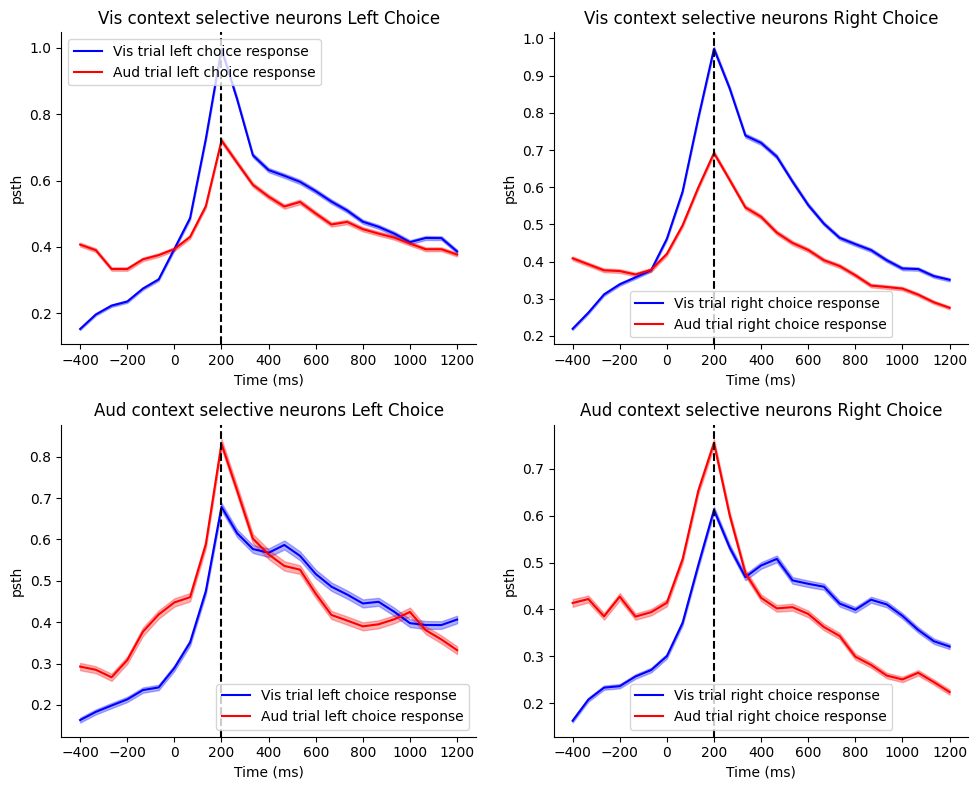

In [155]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_psth[vis_left_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_psth[vis_left_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,0], label='Aud trial left choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Vis context selective neurons Left Choice')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_psth[vis_right_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_psth[vis_right_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,1], label='Aud trial right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Vis context selective neurons Right Choice')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_psth[aud_left_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,0], label='Vis trial left choice response')
plot_with_error_shading(aud_left_choice_psth[aud_left_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,0], label='Aud trial left choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Aud context selective neurons Left Choice')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_right_choice_psth[aud_right_context_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,1], label='Vis trial right choice response')
plot_with_error_shading(aud_right_choice_psth[aud_right_context_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,1], label='Aud trial right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Aud context selective neurons Right Choice')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [63]:
alpha = 0.05
vis_left_choice_neuron_idx =  np.where((vis_left_choice_pval<alpha) & (vis_right_choice_pval>alpha))[0]
aud_left_choice_neuron_idx = np.where((aud_left_choice_pval<alpha) & (aud_right_choice_pval>alpha))[0]
vis_right_choice_neuron_idx = np.where((vis_right_choice_pval<alpha) & (vis_left_choice_pval>alpha))[0]
aud_right_choice_neuron_idx = np.where((aud_right_choice_pval<alpha) & (aud_left_choice_pval>alpha))[0]

In [ ]:

fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_beta[vis_left_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,0], label='Left choice response')
plot_with_error_shading(vis_right_choice_beta[vis_left_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,0], label='Right choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Left Choice selective neurons vis trials')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_beta[vis_right_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0,1], label='Left choice response')
plot_with_error_shading(vis_right_choice_beta[vis_right_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0,1], label='Right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Right Choice selective neurons vis trials')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_beta[aud_left_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,0], label='Left choice response')
plot_with_error_shading(aud_right_choice_beta[aud_left_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,0], label='Right choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Left Choice selective neurons aud trials')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_beta[aud_right_choice_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1,1], label='Left choice response')
plot_with_error_shading(aud_right_choice_beta[aud_right_choice_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1,1], label='Right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Right Choice selective neurons aud trials')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('Beta')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(10,8))
plot_with_error_shading(vis_left_choice_psth[vis_left_choice_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,0], label='Left choice response')
plot_with_error_shading(vis_right_choice_psth[vis_left_choice_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,0], label='Right choice response')
axes[0,0].axvline(x=200, color='black', linestyle='--')
axes[0,0].set_title('Left Choice selective neurons vis trials')
axes[0,0].set_xlabel('Time (ms)')
axes[0,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(vis_left_choice_psth[vis_right_choice_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0,1], label='Left choice response')
plot_with_error_shading(vis_right_choice_psth[vis_right_choice_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0,1], label='Right choice response')
axes[0,1].axvline(x=200, color='black', linestyle='--')
axes[0,1].set_title('Right Choice selective neurons vis trials')
axes[0,1].set_xlabel('Time (ms)')
axes[0,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_psth[aud_left_choice_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,0], label='Left choice response')
plot_with_error_shading(aud_right_choice_psth[aud_left_choice_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,0], label='Right choice response')
axes[1,0].axvline(x=200, color='black', linestyle='--')
axes[1,0].set_title('Left Choice selective neurons aud trials')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plot_with_error_shading(aud_left_choice_psth[aud_right_choice_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1,1], label='Left choice response')
plot_with_error_shading(aud_right_choice_psth[aud_right_choice_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1,1], label='Right choice response')
axes[1,1].axvline(x=200, color='black', linestyle='--')
axes[1,1].set_title('Right Choice selective neurons aud trials')
axes[1,1].set_xlabel('Time (ms)')
axes[1,1].set_ylabel('psth')
axes[0,0].legend(loc='upper left')
plt.tight_layout()
plt.show()

In [34]:
assert(vis_left_choice_psth.shape == vis_right_choice_psth.shape == aud_left_choice_psth.shape == aud_right_choice_psth.shape)

In [ ]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
choice_onset_idx = np.where(psth_timepoint == 0)[0][0]
movement_onset_idx = np.where(psth_timepoint == 200)[0][0]
t_choice_window = np.arange(choice_onset_idx, movement_onset_idx)
t_baseline = np.arange(0, choice_onset_idx)


In [3]:
agg_data['AE_L2']['20250624_valvesilent']['arm1']['stat'][1]['bootstrap_p_value'].shape

NameError: name 'agg_data' is not defined

In [35]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [ ]:
def loo_reconstruct_activity(neuron, X, preds, full_predictors, exact_match=True):
    """
    Reconstruct activity for a single neuron using the full model and a
    leave-one-out (LOO) version where all columns belonging to `pred` are removed
    (by zeroing their betas). No refitting is performed.

    Parameters
    ----------
    neuron : dict
        Must contain:
          - 'beta': (P,) or (1,P) array of weights for this neuron (matches X columns)
          - 'intercept': scalar
    X : array, shape (T, P)
        Design matrix used to fit the model (same column order as full_predictors).
    pred : list of str
        Unique predictor name to leave out (matches columns in `full_predictors`).
    full_predictors : list[str] of length P
        Names for each column of X (e.g., expanded supports for events).
    exact_match : bool, default True
        If True, match columns where name == pred or name startswith(pred).
        If False, use substring containment (pred in name).

    Returns
    -------
    y_full : (T,) ndarray
        Reconstruction with all predictors: X @ beta + intercept.
    y_loo : (T,) ndarray
        Reconstruction with `pred` columns removed (their contribution zeroed).
    contrib : (T,) ndarray
        The contribution of `pred` alone (y_full - y_loo).
    idx : (K,) ndarray
        Integer indices of columns belonging to `pred`.
    """
    beta = np.asarray(neuron['beta']).ravel()
    b0 = float(neuron.get('intercept', 0.0))

    if X.shape[1] != beta.size:
        raise ValueError(f"Shape mismatch: X has {X.shape[1]} columns but beta has {beta.size}.")

    # pick columns for this unique predictor
    all_idx = []
    if exact_match:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if (nm == pred) or nm.startswith(pred)],
                dtype=int
            )
            all_idx.append(idx)
    else:
        for pred in preds:
            idx = np.array(
                [i for i, nm in enumerate(full_predictors) if pred in nm],
                dtype=int
            )
            all_idx.append(idx)
    all_idx = np.concatenate(all_idx)
    print(idx)
    # full reconstruction
    y_full = X @ beta + b0

    # contribution of the predictor's columns
    if all_idx.size > 0:
        contrib = X[:, all_idx] @ beta[all_idx]
    else:
        contrib = np.zeros(X.shape[0], dtype=float)

    # LOO reconstruction (remove that contribution)
    y_loo = y_full - contrib

    return y_full, y_loo
    

In [ ]:
def plot_loo_reconstruction(neuron, design_matrix, table_for_img, pred, loo_pred = None, full_predictors = predictors, psth = None,psth_time_start = None, psth_time_end = None, psth_timepoint = None, ax = None, color = 'blue'):
    """
    Reconstruct activity for a single neuron using the full model and a leave-one-out (LOO) version where all columns belonging to `pred` are removed (by zeroing their betas). 
    No refitting is performed.
    If loo_pred is None, the function will use the full model and remove the columns belonging to `pred`.
    If loo_pred is not None, the function will use the full model and remove the columns belonging to the list of predictors in loo_pred.
    """
    if loo_pred is None:
        y_full, y_loo = loo_reconstruct_activity(neuron, design_matrix, [pred], full_predictors = predictors, exact_match=False)
    else:
        y_full, y_loo = loo_reconstruct_activity(neuron, design_matrix, loo_pred, full_predictors = predictors, exact_match=False)
    y_full = np.concatenate([np.zeros(table_for_img['ruleCue_times'][0]), y_full])
    y_loo = np.concatenate([np.zeros(table_for_img['ruleCue_times'][0]), y_loo])
    

    psth_frame_idx = find_frame_indices(table_for_img, 15, (psth_time_start, psth_time_end), pred).astype(int)
    
    y_full_psth = np.squeeze(get_trial_PSTH(y_full.reshape(1, -1), psth_frame_idx, zscore=False))
    y_full_mean_psth = np.nanmean(y_full_psth, axis=0)
    y_full_bsl_mean = np.nanmean(y_full_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
    
    y_loo_psth = np.squeeze(get_trial_PSTH(y_loo.reshape(1, -1), psth_frame_idx, zscore=False))
    y_loo_mean_psth = np.nanmean(y_loo_psth, axis=0)
    y_loo_bsl_mean = np.nanmean(y_loo_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
    #plot_with_error_shading(y_full_psth-y_full_bsl_mean, time_points=psth_timepoint, color='blue', ax=ax, label='Full model')
    #plot_with_error_shading(y_loo_psth-y_loo_bsl_mean, time_points=psth_timepoint, color='red', ax=ax, label='LOO model')
    ax.plot(psth_timepoint, y_full_mean_psth-y_full_bsl_mean, color=color, label='Full model', linewidth = 4)
    ax.plot(psth_timepoint, y_loo_mean_psth-y_loo_bsl_mean, color=color, label='LOO model', linestyle='--', linewidth = 2)
    if psth is None:
        raw_psth = neuron[pred+'_psth_raw']
        psth_bsl_mean = np.nanmean(raw_psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
        bsl_corr_psth = raw_psth-psth_bsl_mean
        plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax, label='Neuron PSTH')
    else:
        if psth.ndim != 1:
            psth_bsl_mean = np.nanmean(psth[:, np.arange(0, int(np.abs(psth_time_start)/0.066))].ravel())
            bsl_corr_psth = psth-psth_bsl_mean
            plot_with_error_shading(bsl_corr_psth, time_points=psth_timepoint, color=color, ax=ax, label='Neuron PSTH')
        else:
            psth_bsl_mean = np.nanmean(psth[np.arange(0, int(np.abs(psth_time_start)/0.066))])
            bsl_corr_psth = psth-psth_bsl_mean
            ax.plot(psth_timepoint, bsl_corr_psth, color=color, label='Neuron PSTH', linewidth = 2)
    # plt.show()



In [113]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

In [ ]:
vis_left_choice_psth_raw.shape

(80968, 5)

In [ ]:
fig, ax = plt.subplots(1,1, figsize=(10,8))
pred1 = 'left_aud_stimOn_times'
id =20000
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = ax, color = 'blue')

plt.show()

-0.00412551951402905


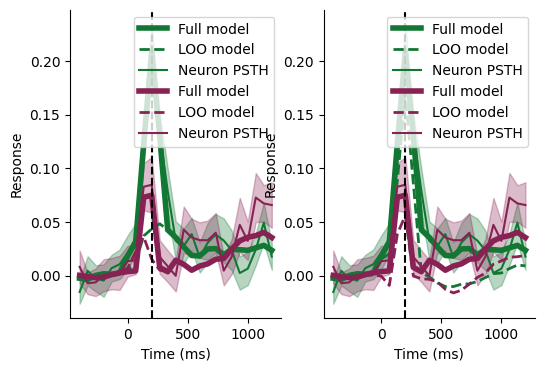

In [108]:
left_choice_color = '#117733'
right_choice_color = '#882255'
pred1 = 'vis_left_choice_times'
pred2 = 'vis_right_choice_times'
sorted_indices = np.argsort(vis_right_choice_r2 - vis_left_choice_r2)[::-1]
id = sorted_indices[-100]
print((vis_right_choice_r2 - vis_left_choice_r2)[id])
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
psth1 = vis_left_choice_psth_raw[id]
psth2 = vis_right_choice_psth_raw[id]
fig, axes = plt.subplots(1,2, figsize=(6,4))
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0], color = left_choice_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0], color = right_choice_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[1], color = left_choice_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[1], color = right_choice_color)
axes[0].axvline(x=200, color='black', linestyle='--')
axes[1].axvline(x=200, color='black', linestyle='--')
plt.show()

In [92]:
print(m, d, a, i)

AF_R3 20250828_valvesilent arm1 55


Reward stuff

In [10]:
t = agg_data['AE_L2']['20250624_valvesilent']['arm1']['table_for_img']
np.array(t['reward_consume_times']-t['feedback_times'])

array([ nan,  nan,   4.,  nan, 112.,  41.,  nan,   2.,  18.,   4.,  nan,
         1.,  nan,  nan,   4.,   3.,  nan,   2.,  23.,  nan,   4.,  nan,
        nan,  10.,  nan,  nan,  nan,   1.,  nan,  nan,  nan,  nan,  nan,
         2.,   1.,  nan,   3.,  nan,   3.,   2.,  nan,  nan,  54.,  nan,
         1.,   6.,  nan,  nan,  nan,   4.,  nan,  nan,   2.,  nan,  nan,
         5.,  nan,  nan,  nan,  nan,  nan,  25.,  nan,   3.,  nan,  nan,
         1.,  nan,   1.,  nan,  nan,   3.,  nan,  nan,  nan,   1.,  nan,
         3.,  nan,  nan,  nan,  nan,   3.,  nan,  nan,  nan,  nan,  nan,
         3.,  nan,  nan,  nan,  41.,  nan,  64.,   1.,  51.,   1.,  nan,
        nan,   2.,   1.,  nan,  nan,   4.,  nan,   7.,   9.,  nan,   3.,
         2.,  nan,   2.,   3.,   2.,  nan,  nan,   3.,  nan,  nan,  nan,
        10.,  nan,   2.,  nan,  nan,   2.,  nan,   1.,  nan,   2.,  nan,
         2.,   4.,  nan,   5.,   1.,   1.,   1.,   5.,  nan,  nan,   1.,
        nan,  nan,   1.,  nan,   2.,  nan,  37.,   

In [13]:
def get_agg_data_reward_psth(agg_data, mouse_ids, column_name, arms=('arm1', 'arm2'), raw = False, long_rt = False):
    """
    Aggregate PSTHs across mice/dates/arms efficiently.
    """
    if not raw:
        col_key = f"{column_name}_psth"
    else:
        col_key = f"{column_name}_psth_raw"
    blocks = []
    rt_info = {'mouse': [], 'date': [], 'arm': [], 'neuron_idx': []}

    for mouse in mouse_ids:
        
        mouse_data = agg_data.get(mouse, {})
        for date, day in mouse_data.items():
            print('processing mouse: ', mouse, 'date: ', date)
            # filters
            if 'training' in date:
                continue
            if column_name and 'reward' in column_name and 'valvesilent' not in date:
                continue
            if column_name and 'punish' in column_name and 'punishsilent' not in date:
                continue
            
            for arm in arms:
                arm_dict = day.get(arm)
                if arm_dict is None:
                    continue

                stats = arm_dict.get('stat', [])
                if len(stats) == 0:
                    continue
                if long_rt: # only for reward variable
                    t = arm_dict.get('table_for_img').copy()
                    t_filtered = t[t[column_name]>0].reset_index(drop=True)
                    t_filtered_longrt = t_filtered[(t_filtered['reward_consume_times']-t_filtered['feedback_times'])>3]
                    long_rt_idx = t_filtered_longrt.index.values
                batch = []
                for i, neuron in enumerate(stats):
                    arr = neuron.get(col_key)
                    if long_rt:
                        arr = arr[long_rt_idx]
                    arr = np.mean(arr, axis=0) # take trial average of psth
                    if arr is None:
                        continue
                    a = np.asarray(arr)
                    if a.ndim != 1:
                        a = a.reshape(-1)
                    batch.append(a)
                    rt_info['mouse'].append(mouse)
                    rt_info['date'].append(date)
                    rt_info['arm'].append(arm)
                    rt_info['neuron_idx'].append(i)

                if batch:
                    blocks.append(np.stack(batch, axis=0))

    rt = np.concatenate(blocks, axis=0) if blocks else np.empty((0, 0), dtype=float)
    return rt, rt_info


In [14]:
long_rt = False
vis_reward_psth_raw, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_reward_times', raw = True, long_rt = long_rt)
aud_reward_psth_raw, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_reward_times', raw = True, long_rt = long_rt)
vis_reward_psth, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='vis_reward_times', raw = False, long_rt = long_rt)
aud_reward_psth, psth_info = get_agg_data_reward_psth(agg_data=agg_data, mouse_ids = mouse_ids, column_name='aud_reward_times', raw = False, long_rt = long_rt)

processing mouse:  AE_L2 date:  20250612
processing mouse:  AE_L2 date:  20250624_valvesilent
processing mouse:  AE_L2 date:  20250701_valvesilent
processing mouse:  AE_L2 date:  20250708_valvesilent
processing mouse:  AE_L2 date:  20250715_valvesilent
processing mouse:  AE_L2 date:  20250729_valvesilent
processing mouse:  AE_L2 date:  20250814_valvesilent_punishsilent
processing mouse:  AE_L2 date:  20250821_valvesilent_punishsilent
processing mouse:  AE_L2 date:  training
processing mouse:  AE_L3 date:  20250612
processing mouse:  AE_L3 date:  20250617_valvesilent
processing mouse:  AE_L3 date:  20250624_valvesilent
processing mouse:  AE_L3 date:  20250701_valvesilent
processing mouse:  AE_L3 date:  20250708_valvesilent
processing mouse:  AE_L3 date:  20250722_valvesilent
processing mouse:  AE_L3 date:  20250729_valvesilent
processing mouse:  AE_L3 date:  20250812_valvesilent
processing mouse:  AE_L3 date:  20250820_valvesilent
processing mouse:  AE_L3 date:  20250828_valvesilent
pro

In [117]:
vis_reward_beta, vis_reward_pval, vis_reward_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='vis_reward_times')
aud_reward_beta, aud_reward_pval, aud_reward_r2, beta_info = get_agg_data_beta(agg_data=agg_data, mouse_ids = mouse_ids, unique_predictors = unique_predictors, column_name='aud_reward_times')


In [118]:
alpha = 0.05
vis_reward_neuron_idx =  np.where((vis_reward_pval<alpha) & (aud_reward_pval>alpha))[0]
aud_reward_neuron_idx = np.where((aud_reward_pval<alpha) & (vis_reward_pval>alpha))[0]
print(len(vis_reward_neuron_idx))
print(len(aud_reward_neuron_idx))

7942
6526


In [17]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_psth.shape[1])
beta_timepoint = np.linspace(0,1000,vis_reward_beta.shape[1])

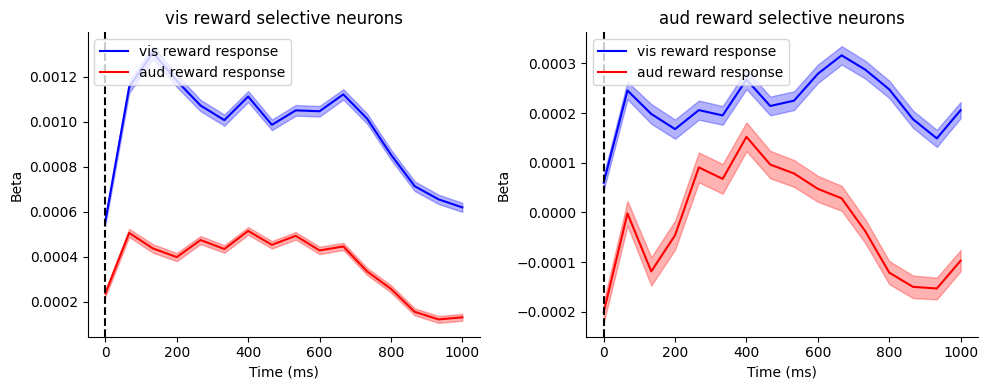

In [18]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
plot_with_error_shading(vis_reward_beta[vis_reward_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[0], label='vis reward response')
plot_with_error_shading(aud_reward_beta[vis_reward_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[0], label='aud reward response')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('vis reward selective neurons')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('Beta')
axes[0].legend(loc='upper left')
plot_with_error_shading(vis_reward_beta[aud_reward_neuron_idx], time_points=beta_timepoint, color='blue', ax=axes[1], label='vis reward response')
plot_with_error_shading(aud_reward_beta[aud_reward_neuron_idx], time_points=beta_timepoint, color='red', ax=axes[1], label='aud reward response')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('aud reward selective neurons')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('Beta')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

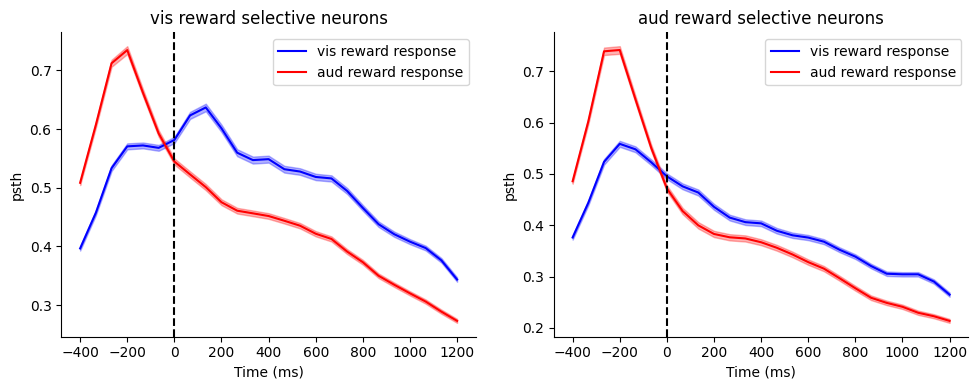

In [19]:
fig, axes = plt.subplots(1,2, figsize=(10,4))
plot_with_error_shading(vis_reward_psth[vis_reward_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[0], label='vis reward response')
plot_with_error_shading(aud_reward_psth[vis_reward_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[0], label='aud reward response')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_title('vis reward selective neurons')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('psth')
axes[0].legend(loc='upper right')
plot_with_error_shading(vis_reward_psth[aud_reward_neuron_idx], time_points=psth_timepoint, color='blue', ax=axes[1], label='vis reward response')
plot_with_error_shading(aud_reward_psth[aud_reward_neuron_idx], time_points=psth_timepoint, color='red', ax=axes[1], label='aud reward response')
axes[1].axvline(x=0, color='black', linestyle='--')
axes[1].set_title('aud reward selective neurons')
axes[1].set_xlabel('Time (ms)')
axes[1].set_ylabel('psth')
axes[1].legend(loc='upper right')

plt.tight_layout()
plt.show()

In [37]:
unique_predictors

['vis_ruleCue_times',
 'aud_ruleCue_times',
 'left_vis_stimOn_times',
 'right_vis_stimOn_times',
 'left_aud_stimOn_times',
 'right_aud_stimOn_times',
 'vis_left_choice_times',
 'vis_right_choice_times',
 'aud_left_choice_times',
 'aud_right_choice_times',
 'vis_reward_times',
 'aud_reward_times',
 'vis_punish_times',
 'aud_punish_times',
 'omission_times',
 'previous_feedbackType',
 'reward_history',
 'body',
 'lick',
 'face',
 'pupil_area',
 'pupil_xpos',
 'pupil_ypos',
 'vel']

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


0.013638155144808543


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


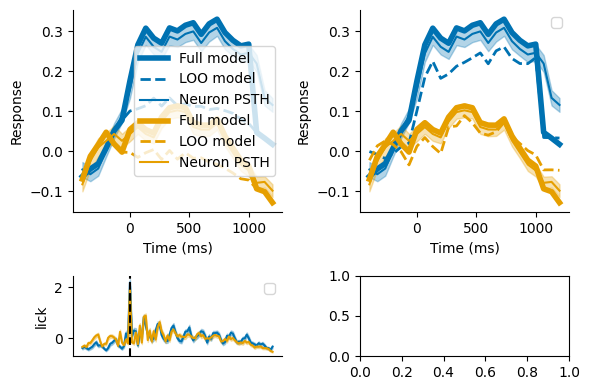

In [159]:
fig, axes = plt.subplots(2, 2, gridspec_kw={'height_ratios': [5, 2]}, figsize=(6,4))
vis_color = '#0072B2'
aud_color = '#E69F00'
pred1 = 'vis_reward_times'
pred2 = 'aud_reward_times'
sorted_indices = np.argsort(vis_reward_r2 - aud_reward_r2)[::-1]
id = sorted_indices[0]
print((vis_reward_r2 - aud_reward_r2)[id])
m = beta_info['mouse'][id]
d = beta_info['date'][id]
a = beta_info['arm'][id]
i = beta_info['neuron_idx'][id]
neuron = agg_data[m][d][a]['stat'][i]
dm = agg_data[m][d][a]['design_matrix']
tf = agg_data[m][d][a]['table_for_img']
# psth1 = vis_left_choice_psth_raw[id]
# psth2 = vis_right_choice_psth_raw[id]
plot_loo_reconstruction(neuron, dm, tf, pred=pred1, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = vis_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,0], color = aud_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred1, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = vis_color)

plot_loo_reconstruction(neuron, dm, tf, pred=pred2, loo_pred=['face', 'body', 'lick'], full_predictors = predictors, 
                        psth = None, psth_time_start = psth_time_start,  psth_time_end = psth_time_end, 
                        psth_timepoint = psth_timepoint, ax = axes[0,1], color = aud_color)

axes[0,1].legend([])


lick = agg_data[m][d]
lick = agg_data[m][d]['lick']
tf_v = agg_data[m][d]['table_for_video']
v_vis_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==0], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
v_aud_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==1], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
vis_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_vis_reward_frame_idx, zscore=True).squeeze()
aud_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_aud_reward_frame_idx, zscore=True).squeeze()
lick_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_lick.shape[1])
plot_with_error_shading(vis_reward_lick, time_points=lick_timepoint, color=vis_color, ax=axes[1,0])
plot_with_error_shading(aud_reward_lick, time_points=lick_timepoint, color=aud_color, ax=axes[1,0])
axes[1,0].axvline(x=0, color='black', linestyle='--')
axes[1,0].set_xlabel('Time (ms)')
axes[1,0].set_ylabel('lick') 
axes[1,0].xaxis.set_visible(False) 
plt.tight_layout()
plt.show()

Text(0, 0.5, 'psth')

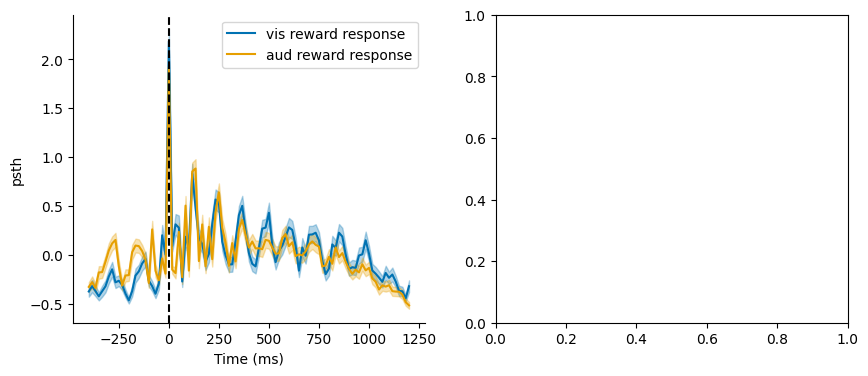

In [153]:
lick = agg_data[m][d]['lick']
tf_v = agg_data[m][d]['table_for_video']
v_vis_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==0], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
v_aud_reward_frame_idx = find_frame_indices(tf_v[tf_v['modality']==1], 60.4, (psth_time_start, psth_time_end), 'reward_consume_times').astype(int)
vis_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_vis_reward_frame_idx, zscore=True).squeeze()
aud_reward_lick = get_trial_PSTH(np.expand_dims(lick[:,0], axis=0), v_aud_reward_frame_idx, zscore=True).squeeze()
fig, axes = plt.subplots(1,2, figsize=(10,4))
lick_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_reward_lick.shape[1])
plot_with_error_shading(vis_reward_lick, time_points=lick_timepoint, color=vis_color, ax=axes[0], label='vis reward response')
plot_with_error_shading(aud_reward_lick, time_points=lick_timepoint, color=aud_color, ax=axes[0], label='aud reward response')
axes[0].axvline(x=0, color='black', linestyle='--')
axes[0].set_xlabel('Time (ms)')
axes[0].set_ylabel('psth')  



In [120]:
print(m, d, a, i)

AF_L3 20250909_valvesilent_punishsilent arm2 37


Decoding stuff

In [43]:
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ---- assumes your loo_reconstruct_activity(), find_frame_indices(), etc. are already defined ----

def build_residual_tensor(
    neurons,                 # list[dict], each has neuron['beta'], neuron['intercept'],
    dff,                     # (n_neurons, n_time), need to have same length as neurons
    design_matrix,           # (T_model, P)
    predictors,              # list[str] length P (column names for design_matrix)
    table_for_img,           # dict-like with trial info; needs ['ruleCue_times'] and label cols
    preds_to_exclude,        # list[str]; predictors to leave out (e.g., ['choice']), should be same as align_pred?
    psth_time_start,         # e.g., -1.0  (seconds; whatever your find_frame_indices expects)
    psth_time_end,           # e.g., 1.0
    align_pred,              # str passed to find_frame_indices, e.g., 'ruleCue' or your event name. the activity around which the prediction is made
    frames_per_s=15,         # your frame rate if find_frame_indices needs it
):
    """
    Returns:
      residual_tensor: (n_neurons, n_trials, n_time) ndarray
      psth_frame_idx:  (n_trials, n_time) ndarray of absolute frame indices used
      
    """
    assert(len(neurons) == dff.shape[0])
    # get the per-trial absolute frame indices covering the time window
    psth_frame_idx = find_frame_indices(
        table_for_img,
        frames_per_s,
        (psth_time_start, psth_time_end),
        align_pred
    ).astype(int)  # shape: (n_trials, n_time)
    n_trials, n_time = psth_frame_idx.shape
    trial_mask = ~np.isnan(table_for_img[align_pred])
    # build residuals for each neuron
    pad_len = int(table_for_img['ruleCue_times'][0])  # how many zeros to pre-pad (your convention)
    residual_blocks = []

    for i, nrn in enumerate(neurons):
        # print('building residual tensor for neuron: ', i)
        # predict with LOO (exclude chosen predictors, no refit)
        _, y_loo = loo_reconstruct_activity(
            nrn, design_matrix, preds_to_exclude, full_predictors=predictors, exact_match=False
        )
        # align y_loo to F with the same pre-padding convention
        y_loo_aligned = np.concatenate([np.zeros(pad_len, dtype=float), y_loo])
        assert(len(y_loo_aligned) == table_for_img['intervals_1'].iloc[-1])
        # residual = raw - y_loo
        F = np.asarray(dff[i]).ravel()
        F = F[:len(y_loo_aligned)]
        if F.shape[0] != y_loo_aligned.shape[0]:
            raise ValueError(f"Length mismatch: F={F.shape[0]} vs y_loo_aligned={y_loo_aligned.shape[0]}")
        resid = F - y_loo_aligned

        # slice residuals into (n_trials, n_time) via advanced indexing
        # (broadcasting: for each trial row, grab those absolute frames)
        resid_trials_time = resid[psth_frame_idx]  # shape (n_trials, n_time)
        residual_blocks.append(resid_trials_time)

    residual_tensor = np.stack(residual_blocks, axis=0)  # (n_neurons, n_trials, n_time)
    return residual_tensor, psth_frame_idx, trial_mask


def decode_timecourse_L1(
    residual_tensor,     # (n_neurons, n_trials, n_time)
    labels,              # (n_trials,) array-like with 2 classes (e.g., choice ∈ {-1, 1} or modality ∈ {0, 1})
    trial_mask=None,     # optional boolean mask length n_trials to subset (e.g., only correct trials)
    n_splits=5,
    C=1.0,               # inverse regularization strength
    l1_ratio=1.0,        # 1.0 = pure L1; (0,1) = elastic-net
    random_state=0,
    max_iter=5000,
):
    """
    Returns:
      acc_time: (n_time,) mean CV accuracy per timepoint
      acc_std_time: (n_time,) std across folds
      majority_baseline: float baseline accuracy of majority class (on masked trials)
    """
    n_neurons, n_trials, n_time = residual_tensor.shape
    labels = np.asarray(labels).ravel()
    if labels.shape[0] != n_trials:
        raise ValueError("labels length must match number of trials in residual_tensor")

    # mask trials if requested
    if trial_mask is None:
        trial_mask = np.ones(n_trials, dtype=bool)
    else:
        trial_mask = np.asarray(trial_mask, dtype=bool)
        if trial_mask.shape[0] != n_trials:
            raise ValueError("trial_mask length must match number of trials")

    # ensure binary labels and keep only masked trials
    y_all = labels[trial_mask]
    if len(np.unique(y_all)) != 2:
        raise ValueError("labels must contain exactly two classes after masking")

    # majority baseline on masked trials
    (vals, counts) = np.unique(y_all, return_counts=True)
    majority_baseline = counts.max() / counts.sum()

    # CV splitter
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    acc_time = np.zeros(n_time, dtype=float)
    acc_std_time = np.zeros(n_time, dtype=float)

    # loop over time points
    for t in range(n_time):
        # X_t: (n_trials_masked, n_neurons)
        X_t = residual_tensor[:, trial_mask, t].T  # trials x neurons
        y_t = y_all

        # handle NaNs/Infs safely: replace with 0 after standardization (common approach for sparse-ish signals)
        fold_accs = []
        for train_idx, test_idx in skf.split(X_t, y_t):
            Xtr, Xte = X_t[train_idx], X_t[test_idx]
            ytr, yte = y_t[train_idx], y_t[test_idx]

            # standardize features (fit on train, apply to test)
            scaler = StandardScaler(with_mean=True, with_std=True)
            Xtr = scaler.fit_transform(Xtr)
            Xte = scaler.transform(Xte)

            # replace any remaining NaNs/Infs with zeros
            if not np.isfinite(Xtr).all():
                Xtr = np.nan_to_num(Xtr, nan=0.0, posinf=0.0, neginf=0.0)
            if not np.isfinite(Xte).all():
                Xte = np.nan_to_num(Xte, nan=0.0, posinf=0.0, neginf=0.0)

            # L1 (or elastic-net if l1_ratio < 1) logistic regression
            clf = LogisticRegression(
                penalty='elasticnet',
                solver='saga',
                l1_ratio=l1_ratio,
                C=C,
                max_iter=max_iter,
                n_jobs=-1,
                random_state=random_state,
            )
            clf.fit(Xtr, ytr)
            acc = clf.score(Xte, yte)
            fold_accs.append(acc)

        acc_time[t] = np.mean(fold_accs)
        acc_std_time[t] = np.std(fold_accs, ddof=1) if len(fold_accs) > 1 else 0.0

    return acc_time, acc_std_time, majority_baseline


def population_decode_timecourse(
    neurons,
    dff,
    design_matrix,
    predictors,
    table_for_img,
    preds_to_exclude,        # e.g., ['choice'] or ['choice_left','choice_right'] depending on your naming
    psth_time_start,         # e.g., -0.5
    psth_time_end,           # e.g.,  1.0
    align_pred,              # e.g., 'ruleCue'
    label_key='choice',      # 'choice' (−1/1) or 'modality' (0/1), or pass your own vector below
    custom_labels=None,      # optional override for labels (length = n_trials)
    trial_mask=None,         # optional bool mask to subset trials
    frames_per_s=15,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=5000,
    return_tensor=False,
):
    """
    One-call convenience wrapper: builds residual tensor and runs decoding.
    Returns:
      results: dict with fields:
        - 'timepoints' (np.ndarray): time axis in seconds inferred from (start, end, frames_per_s)
        - 'acc' (np.ndarray): mean CV accuracy per timepoint
        - 'acc_std' (np.ndarray): std across folds per timepoint
        - 'baseline' (float): majority-class baseline on masked trials
        - 'psth_frame_idx' (np.ndarray): (n_trials, n_time)
        - 'residual_tensor' (optional, if return_tensor=True): (n_neurons, n_trials, n_time)
    """
    residual_tensor, psth_frame_idx, trial_mask = build_residual_tensor(
        neurons, dff,design_matrix, predictors, table_for_img,
        preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s
    )

    # labels
    if custom_labels is not None:
        labels = np.asarray(custom_labels).ravel()
    else:
        labels = np.asarray(table_for_img[label_key]).ravel()
    labels = labels[trial_mask]
    new_trial_mask = trial_mask[trial_mask] # residual tensor is pre-selected for non-nan (like only reward trials)
    
    # Automatically mask out invalid 'choice == 0' trials
    if label_key == 'choice':
        zero_mask = labels != 0
        new_trial_mask = new_trial_mask & zero_mask
    acc, acc_std, baseline = decode_timecourse_L1(
        residual_tensor, labels,
        trial_mask=new_trial_mask,
        n_splits=n_splits, C=C, l1_ratio=l1_ratio,
        random_state=random_state, max_iter=max_iter
    )

    n_time = psth_frame_idx.shape[1]
    timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

    out = dict(
        timepoints=timepoints,
        acc=acc,
        acc_std=acc_std,
        baseline=baseline,
        psth_frame_idx=psth_frame_idx
    )
    if return_tensor:
        out['residual_tensor'] = residual_tensor
    return out


def population_decode_timecourse_session(
    data,
    mouse,
    date,
    predictors,
    preds_to_exclude,        # e.g., ['choice'] or ['choice_left','choice_right'] depending on your naming
    psth_time_start,         # e.g., -0.5
    psth_time_end,           # e.g.,  1.0
    align_pred,              # e.g., 'ruleCue'
    label_key='choice',      # 'choice' (−1/1) or 'modality' (0/1), or pass your own vector below
    custom_labels=None,      # optional override for labels (length = n_trials)
    trial_mask=None,         # optional bool mask to subset trials
    frames_per_s=15,
    C=1.0,
    l1_ratio=1.0,
    n_splits=5,
    random_state=0,
    max_iter=5000,
    return_tensor=False,
):
    """
    One-call convenience wrapper: builds residual tensor and runs decoding.
    Returns:
      results: dict with fields:
        - 'timepoints' (np.ndarray): time axis in seconds inferred from (start, end, frames_per_s)
        - 'acc' (np.ndarray): mean CV accuracy per timepoint
        - 'acc_std' (np.ndarray): std across folds per timepoint
        - 'baseline' (float): majority-class baseline on masked trials
        - 'psth_frame_idx' (np.ndarray): (n_trials, n_time)
        - 'residual_tensor' (optional, if return_tensor=True): (n_neurons, n_trials, n_time)
    """
    if 'arm1' in data[mouse][date].keys():
        arm1_dff = np.load(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse,date,'arm1','dff_moving_percentile_pc_lowpass_0p5hz.npy'))
        arm1_neurons = data[mouse][date]['arm1']['stat']
        arm1_design_matrix = data[mouse][date]['arm1']['design_matrix']
        arm1_table_for_img = data[mouse][date]['arm1']['table_for_img']
        arm1_residual_tensor, arm1_psth_frame_idx, arm1_trial_mask = build_residual_tensor(
            arm1_neurons, arm1_dff,arm1_design_matrix, predictors, arm1_table_for_img,
            preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s
        )

    
    if 'arm2' in data[mouse][date].keys():
        arm2_dff = np.load(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse,date,'arm2','dff_moving_percentile_pc_lowpass_0p5hz.npy'))
        arm2_neurons = data[mouse][date]['arm2']['stat']
        arm2_design_matrix = data[mouse][date]['arm2']['design_matrix']
        arm2_table_for_img = data[mouse][date]['arm2']['table_for_img']
        arm2_residual_tensor, arm2_psth_frame_idx, arm2_trial_mask = build_residual_tensor(
            arm2_neurons, arm2_dff,arm2_design_matrix, predictors, arm2_table_for_img,
            preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s
        )
    
    assert(arm1_residual_tensor.shape[1] == arm2_residual_tensor.shape[1])

    if arm1_residual_tensor is not None and arm2_residual_tensor is not None:
        residual_tensor = np.concatenate([arm1_residual_tensor, arm2_residual_tensor], axis=0)
    elif arm1_residual_tensor is not None:
        residual_tensor = arm1_residual_tensor
    elif arm2_residual_tensor is not None:
        residual_tensor = arm2_residual_tensor
    else:
        raise ValueError('No residual tensor found')

    # labels
    if custom_labels is not None:
        labels = np.asarray(custom_labels).ravel()
    else:
        labels = np.asarray(arm1_table_for_img[label_key]).ravel()
    labels = labels[arm1_trial_mask]
    new_trial_mask = arm1_trial_mask[arm1_trial_mask] # residual tensor is pre-selected for non-nan (like only reward trials)
    
    # Automatically mask out invalid 'choice == 0' trials
    if label_key == 'choice':
        zero_mask = labels != 0
        new_trial_mask = new_trial_mask & zero_mask
    acc, acc_std, baseline = decode_timecourse_L1(
        residual_tensor, labels,
        trial_mask=new_trial_mask,
        n_splits=n_splits, C=C, l1_ratio=l1_ratio,
        random_state=random_state, max_iter=max_iter
    )

    n_time = psth_frame_idx.shape[1]
    timepoints = np.linspace(psth_time_start, psth_time_end, n_time)

    out = dict(
        timepoints=timepoints,
        acc=acc,
        acc_std=acc_std,
        baseline=baseline,
        psth_frame_idx=psth_frame_idx
    )
    if return_tensor:
        out['residual_tensor'] = residual_tensor
    return out

In [33]:
def plot_decoding_accuracy(
    results,
    ax=None,
    title=None,
    time_range_ms=None,  # e.g. (-500, 1000)
    show_zero_line=True,
    color='C0',
):
    """
    Plot mean decoding accuracy with ±1 SD and majority baseline.

    Parameters
    ----------
    results : dict
        Output from population_decode_timecourse (must include 'timepoints', 'acc', 'acc_std', 'baseline')
    ax : matplotlib Axes, optional
        Existing axes to plot on. Creates new one if None.
    title : str, optional
        Title for the plot.
    time_range_ms : tuple[float,float], optional
        (start_ms, end_ms) range for x-axis. If None, uses full range of timepoints.
    show_zero_line : bool, default True
        Whether to draw a vertical line at 0 ms.
    color : str, default 'C0'
        Base color for the accuracy curve.
    """
    tp_s = np.asarray(results['timepoints'])
    acc = np.asarray(results['acc'])
    sd  = np.asarray(results['acc_std'])
    base = results.get('baseline', 0.5)

    # Convert timepoints (s) → ms
    tp_ms = tp_s * 1000

    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 2))

    # Main curve
    ax.plot(tp_ms, acc, color=color, lw=2, label='L1-LogReg (CV mean)')
    ax.fill_between(tp_ms, acc - sd, acc + sd, color=color, alpha=0.2, label='±1 SD')

    # Baseline
    ax.axhline(base, ls='--', lw=1.5, color='gray', label=f'Baseline = {base:.2f}')

    # Zero ms vertical line
    if show_zero_line:
        ax.axvline(0, color='k', ls='--', lw=1)

    # Axis labels & limits
    ax.set_xlabel('Time (ms)')
    ax.set_ylabel('Accuracy')
    if time_range_ms is not None:
        ax.set_xlim(*time_range_ms)
    if title:
        ax.set_title(title)

    ax.legend(loc='best')
    return ax

In [26]:
table_for_img = agg_data['AE_L2']['20250715_valvesilent']['arm1']['table_for_img']

In [35]:
date = '20250909_valvesilent_punishsilent'
mouse = 'AF_L3'
arm = 'arm2'
neurons = agg_data[mouse][date][arm]['stat']
arm1_dff = np.load(os.path.join(r'Z:\TM_Lab\Edward\Cerebellum_Imaging\Pcp2-jgcamp8m',mouse,date,arm,'dff_moving_percentile_pc_lowpass_0p5hz.npy'))
dm = agg_data[mouse][date][arm]['design_matrix']
table_for_img = agg_data[mouse][date][arm]['table_for_img']

#psth_time_start = -1.0
#psth_time_end = 1.0

frames_per_s = 15
#residual_tensor, psth_frame_idx = build_residual_tensor(neurons, arm1_dff, dm, predictors, table_for_img, preds_to_exclude, psth_time_start, psth_time_end, align_pred, frames_per_s)

In [45]:
table_for_img

,intervals_0,intervals_1,ruleCue_times,ruleCueTrigger_times,response_times,choice,stimOnTrigger_times,stimOn_times,contrastLeft,contrastRight,...,left_vis_stimOn_times,right_vis_stimOn_times,left_aud_stimOn_times,right_aud_stimOn_times,vis_left_choice_times,vis_right_choice_times,aud_left_choice_times,aud_right_choice_times,previous_feedbackType,reward_history
0,83,242,161,161,188,1,173,176.0,NaN,0.5,...,NaN,174.0,NaN,NaN,NaN,184.0,NaN,NaN,0,0.35
1,263,335,272,271,312,1,289,290.0,0.5,NaN,...,290.0,NaN,NaN,NaN,NaN,307.0,NaN,NaN,-1,0.35
2,357,436,368,367,382,-1,379,380.0,1.0,NaN,...,380.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0.35
3,456,560,474,474,506,1,486,487.0,NaN,1.0,...,NaN,487.0,NaN,NaN,NaN,500.0,NaN,NaN,-1,0.35
4,580,658,590,590,604,-1,602,603.0,1.0,NaN,...,603.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1,0.35
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
334,46481,46531,46488,46488,46507,-1,46500,46501.0,NaN,0.0,...,NaN,NaN,NaN,46500.0,NaN,NaN,46500.0,NaN,1,0.55
335,46551,46665,46582,46581,46611,-1,46593,46594.0,0.0,NaN,...,NaN,NaN,46594.0,NaN,NaN,NaN,46602.0,NaN,1,0.50
336,46685,46765,46693,46692,46742,-1,46704,46728.0,NaN,0.0,...,NaN,NaN,NaN,46705.0,NaN,NaN,NaN,NaN,-1,0.50
337,46784,46907,46793,46792,46853,-1,46805,46805.0,0.0,NaN,...,NaN,NaN,46805.0,NaN,NaN,NaN,46839.0,NaN,1,0.45


In [36]:
align_pred = 'reward_consume_times'
preds_to_exclude = ['vis_reward_times', 'aud_reward_times']

results = population_decode_timecourse(
    neurons=neurons,
    dff=arm1_dff,
    design_matrix=dm,
    predictors=predictors,                 # column names for design_matrix
    table_for_img=table_for_img,
    preds_to_exclude=preds_to_exclude,           # or ['choice_left','choice_right'] if split cols
    psth_time_start=psth_time_start,
    psth_time_end=psth_time_end,
    align_pred=align_pred,
    label_key='modality',                    # uses table_for_img['choice'] (−1 left, +1 right)
    frames_per_s=15,
    C=0.5, l1_ratio=1.0, n_splits=5,
    random_state=42
)

In [ ]:
align_pred = 'ruleCue_times'
preds_to_exclude = ['vis_ruleCue_times', 'aud_ruleCue_times']
fig, ax = plt.subplots(figsize=(4, 2))
dates = list(agg_data['AE_L2'].keys())
results_all = []
for date in dates:
    
    results = population_decode_timecourse_session(
        data=agg_data,
        mouse='AE_L2',
        date=date,
        predictors=predictors,                 # column names for design_matrix 
        preds_to_exclude=preds_to_exclude,           # or ['choice_left','choice_right'] if split cols
        psth_time_start=psth_time_start,
        psth_time_end=psth_time_end,
        align_pred=align_pred,
        label_key='modality',                    # uses table_for_img['choice'] (−1 left, +1 right)
        frames_per_s=15,
        C=0.5, l1_ratio=1.0, n_splits=5,
        random_state=42
    )
    results_all.append(results)

KeyboardInterrupt: 

In [50]:
results

{'timepoints': array([-0.4       , -0.33333333, -0.26666667, -0.2       , -0.13333333,
        -0.06666667,  0.        ,  0.06666667,  0.13333333,  0.2       ,
         0.26666667,  0.33333333,  0.4       ,  0.46666667,  0.53333333,
         0.6       ,  0.66666667,  0.73333333,  0.8       ,  0.86666667,
         0.93333333,  1.        ,  1.06666667,  1.13333333,  1.2       ]),
 'acc': array([0.51186441, 0.58983051, 0.46440678, 0.46440678, 0.49830508,
        0.63050847, 0.49152542, 0.63728814, 0.63050847, 0.46101695,
        0.39661017, 0.72881356, 0.73898305, 0.69152542, 0.63728814,
        0.61355932, 0.56271186, 0.53559322, 0.48474576, 0.34915254,
        0.36271186, 0.35932203, 0.36949153, 0.57966102, 0.66101695]),
 'acc_std': array([0.04853499, 0.0604018 , 0.05439595, 0.03713373, 0.04254204,
        0.03674489, 0.10652377, 0.04254204, 0.05797502, 0.04703199,
        0.06181214, 0.0599243 , 0.03901988, 0.03031957, 0.0844061 ,
        0.04387179, 0.06926379, 0.03514651, 0.01515978,

<Axes: title={'center': 'context decoding from reward'}, xlabel='Time (ms)', ylabel='Accuracy'>

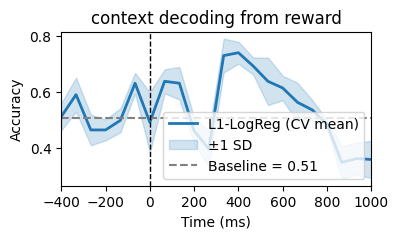

In [51]:
plot_decoding_accuracy(results, title='context decoding from reward', time_range_ms=(-400, 1000))

<Axes: title={'center': 'context decoding from reward'}, xlabel='Time (ms)', ylabel='Accuracy'>

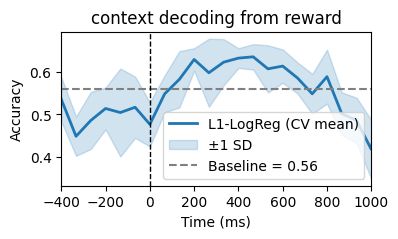

In [37]:
plot_decoding_accuracy(results, title='context decoding from reward', time_range_ms=(-400, 1000))

Scatter plot

In [9]:
neuron['left_aud_stimOn_times_beta']

-1.554312234475219e-16

In [ ]:
pred_x = 'left_aud_stimOn_times'
pred_y = 'vis_reward_times'
x_betas = []
y_betas = []
x_pred_idx = [i for i, name in enumerate(predictors) if pred_x in name]
y_pred_idx = [i for i, name in enumerate(predictors) if pred_y in name]

# Loop through all mice, dates, and arms to collect beta coefficients
for mouse_id in agg_data.keys():
    # if mouse_id != 'J_L2':
    #     continue
    mouse_data = agg_data[mouse_id]
    
    # Loop through all dates (excluding 'training')
    for date in mouse_data.keys():
        #print(date)
        if date == 'training':
            continue
            
        # Check both arm1 and arm2 if they exist
        for arm in ['arm1', 'arm2']:
            if arm in mouse_data[date]:
                neurons = mouse_data[date][arm]
                
                # Loop through all neurons in this arm
                for neuron in neurons:
                    x_beta = np.mean(neuron['beta'][x_pred_idx])
                    y_beta = np.mean(neuron['beta'][y_pred_idx])
                    
                    x_betas.append(x_beta)
                    y_betas.append(y_beta)

# Convert to numpy arrays
x_betas = np.array(x_betas)
y_betas = np.array(y_betas)

# Create the scatter plot
plt.figure(figsize=(10, 8))
plt.scatter(x_betas, y_betas, alpha=0.6, s=20)
plt.xlabel(pred_x, fontsize=18)
plt.ylabel(pred_y, fontsize=18)
plt.title(f'Neuron Response Correlation\n(n={len(x_betas)} neurons from all mice and dates)', fontsize=18)
plt.grid(True, alpha=0.3)

# Make tick labels bigger
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Calculate regression line
slope, intercept, r_value, p_value, std_err = stats.linregress(x_betas, y_betas)

# Plot regression line
x_range = np.linspace(np.min(x_betas), np.max(x_betas), 100)
y_pred = slope * x_range + intercept
plt.plot(x_range, y_pred, 'r-', alpha=0.8, linewidth=2, 
         #label=f'Regression line (R²={r_value**2:.3f})'
         )

# Calculate and display correlation and regression stats
correlation = np.corrcoef(x_betas, y_betas)[0, 1]
plt.text(0.05, 0.8, f'Correlation: {correlation:.3f}\nR²: {r_value**2:.3f}\np-value: {p_value:.2e}', 
         transform=plt.gca().transAxes, fontsize=16, 
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend()
plt.tight_layout()
plt.show()

print(f"Total number of neurons: {len(x_betas)}")
print(f"Correlation coefficient: {correlation:.4f}")
print(f"Regression slope: {slope:.4f}")
print(f"Regression intercept: {intercept:.4f}")
print(f"R-squared: {r_value**2:.4f}")
print(f"P-value: {p_value:.2e}")

In [ ]:
psth_timepoint = np.linspace(psth_time_start*1000,psth_time_end*1000,vis_left_choice_psth.shape[1])
beta_timepoint = np.linspace(0,300,vis_left_choice_beta.shape[1])

Unique Explained Variance Box Plot

In [77]:

unique_explained_cvR = []
full_explained_cvR = []
# Loop through all mice, dates, and arms to collect beta coefficients
for i, pred in enumerate(unique_predictors):
    unique_explained_cvR.append([])
    for mouse_id in agg_data.keys():
        # if mouse_id != 'J_L2':
        #     continue
        mouse_data = agg_data[mouse_id]
        
        # Loop through all dates (excluding 'training')
        for date in mouse_data.keys():
            #print(date)
            if date == 'training':
                continue
            if 'reward' in pred and 'valvesilent' not in date:
                continue
            if 'punish' in pred and 'punishsilent' not in date:
                continue
            # Check both arm1 and arm2 if they exist
            for arm in ['arm1', 'arm2']:
                if arm in mouse_data[date]:
                    neurons = mouse_data[date][arm]['stat']
                    
                    # Loop through all neurons in this arm
                    for neuron in neurons:
                        # Check if both predictors exist for this neuron
                        unique_explained_cvR[i].append(neuron['unique_explained_variance'][i])
                        if i == 0:
                            full_explained_cvR.append(neuron['explained_variance'])

In [ ]:
plt.figure(figsize=(10, 8))

# Create box plot with unique explained variance for each predictor
box_data = [unique_explained_cvR[i] for i in range(len(unique_predictors))]
bp = plt.boxplot(box_data, labels=unique_predictors, patch_artist=True, showfliers=False)

# Customize the plot
plt.xlabel('Predictors')
plt.ylabel('Unique Explained Variance (CV R²)')
plt.title('Unique Explained Variance by Predictor Across All Neurons')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Color the boxes for better visualization
colors = plt.cm.Set3(np.linspace(0, 1, len(unique_predictors)))
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(2, 4))

# Create box plot with full explained variance for all neurons
bp = plt.boxplot([full_explained_cvR], patch_artist=True, showfliers=False)

# Customize the plot
plt.ylabel('Full Model Explained Variance (CV R²)')
plt.title('Full Model Explained Variance Across All Neurons')
plt.xticks([1], ['All Neurons'])
plt.grid(True, alpha=0.3)

# Color the box
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

plt.tight_layout()
plt.show()
